In [187]:
import argparse
import os
import sys
from itertools import product
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import torch
from torch import nn
import torch.nn.functional as F
import seaborn as sns

from tqdm import trange

In [184]:
def sample_poisson(
    rate,
    method: str = "score",
    n_monte_carlo: int = 1,
    upperbound: int = 8,
    tau: float = 0.1,
):
    # rate: Tensor of shape (,)
    if method == "score":
        return torch.poisson(
            rate.unsqueeze(0).expand(
                n_monte_carlo,
            )
        )
    elif method == "GS":
        k = torch.arange(upperbound).float()  # [0, 1, ..., upperbound-1]
        logit_pi = k * rate.log().unsqueeze(-1) - torch.lgamma(
            k + 1
        )  # [logit_pi_0, logit_pi_1, ..., logit_pi_(upperbound-1)]
        # logit_pi = (
        #     k * rate.log().unsqueeze(-1) - rate - torch.lgamma(k + 1)
        # )  # [logit_pi_0, logit_pi_1, ..., logit_pi_(upperbound-1)]
        z_gs_samples = F.gumbel_softmax(
            logit_pi.unsqueeze(0).expand(n_monte_carlo, upperbound), tau=tau, hard=False
        )  # one-hot [z_gs_0, z_gs_1, ..., z_gs_(upperbound-1)]
        z = z_gs_samples @ k  # z = sum_{k=0}^{upperbound-1} z_gs_k * k
        return z
    elif method == "exp":
        u = torch.rand((n_monte_carlo, upperbound))
        z_exp_samples = -(1 - u).log() / rate
        z = (torch.sigmoid((1 - torch.cumsum(z_exp_samples, dim=-1)) / tau)).sum(dim=-1)
        return z


def poisson_log_prob(rate, z):
    return z * rate.log() - rate - torch.lgamma(z + 1)


def compute_upperbound(rate: float, p: float = 1e-2):
    assert rate > 0.0, f"must be positive, got: {rate}"
    pois = stats.poisson(rate)
    n_exp = pois.ppf(1.0 - p)
    return int(n_exp)

[Text(0.5, 0, 'z'),
 Text(0, 0.5, 'density'),
 Text(0.5, 1.0, 'Poisson Sampling Methods Comparison (rate=1.0)')]

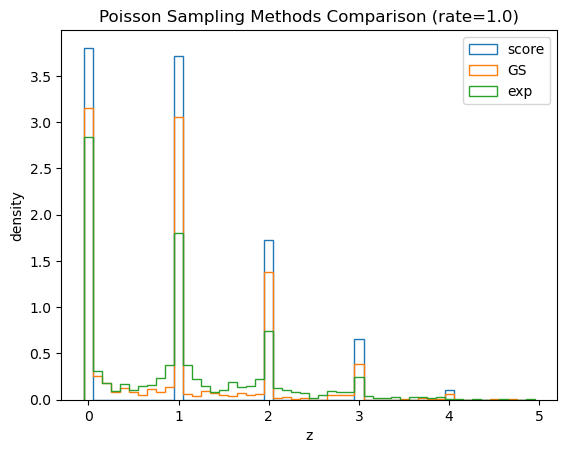

In [136]:
fig, ax = plt.subplots()

rate = torch.tensor(1.0)

for method, color in zip(
    ["score", "GS", "exp"],
    ["C0", "C1", "C2"],
):
    z = sample_poisson(
        rate=rate, method=method, n_monte_carlo=1000, tau=0.1, upperbound=8
    )
    ax.hist(
        z.numpy(),
        density=True,
        bins=np.arange(-0.05, 5, 0.1),
        color=color,
        label=method,
        fill=False,
        histtype="step",
    )
ax.legend()
ax.set(
    xlabel="z",
    ylabel="density",
    title=f"Poisson Sampling Methods Comparison (rate={rate.item()})",
)

## Fixed upperbound

In [137]:
def f(z):
    return z**2


def f_grad_exact(rate):
    return 2 * rate + 1


rate_list = [0.2, 0.5, 1.0, 2.0]
method_list = ["score", "GS", "exp"]
upperbound_list = [5, 8, 10]
tau_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
n_monte_carlo_list = [1, 2, 5, 10]
seed_list = np.arange(3)

In [120]:
df_result = []

for rate, method, upperbound, tau, n_monte_carlo, seed in product(
    rate_list,
    method_list,
    upperbound_list,
    tau_list,
    n_monte_carlo_list,
    seed_list,
):
    if method == "score" and (
        (tau != tau_list[0]) or (upperbound != upperbound_list[0])
    ):
        continue
    torch.manual_seed(seed)
    rate_tensor = torch.tensor(rate, requires_grad=True)
    start_time = time.time()
    z_samples = sample_poisson(
        rate_tensor,
        method=method,
        n_monte_carlo=n_monte_carlo,
        upperbound=upperbound,
        tau=tau,
    )
    f_z = f(z_samples)
    if method == "score":
        loss = (f_z * poisson_log_prob(rate_tensor, z_samples)).mean()
    else:
        loss = f_z.mean()
    loss.backward()
    end_time = time.time()
    df_result.append(
        {
            "rate": rate,
            "method": method,
            "upperbound": upperbound,
            "$\\tau$": tau,
            "n_monte_carlo": n_monte_carlo,
            "seed": seed,
            "time": end_time - start_time,
            "grad_estimate": rate_tensor.grad.item(),
        }
    )
    grad_estimate = rate_tensor.grad.item()
df_result = pd.DataFrame(df_result)

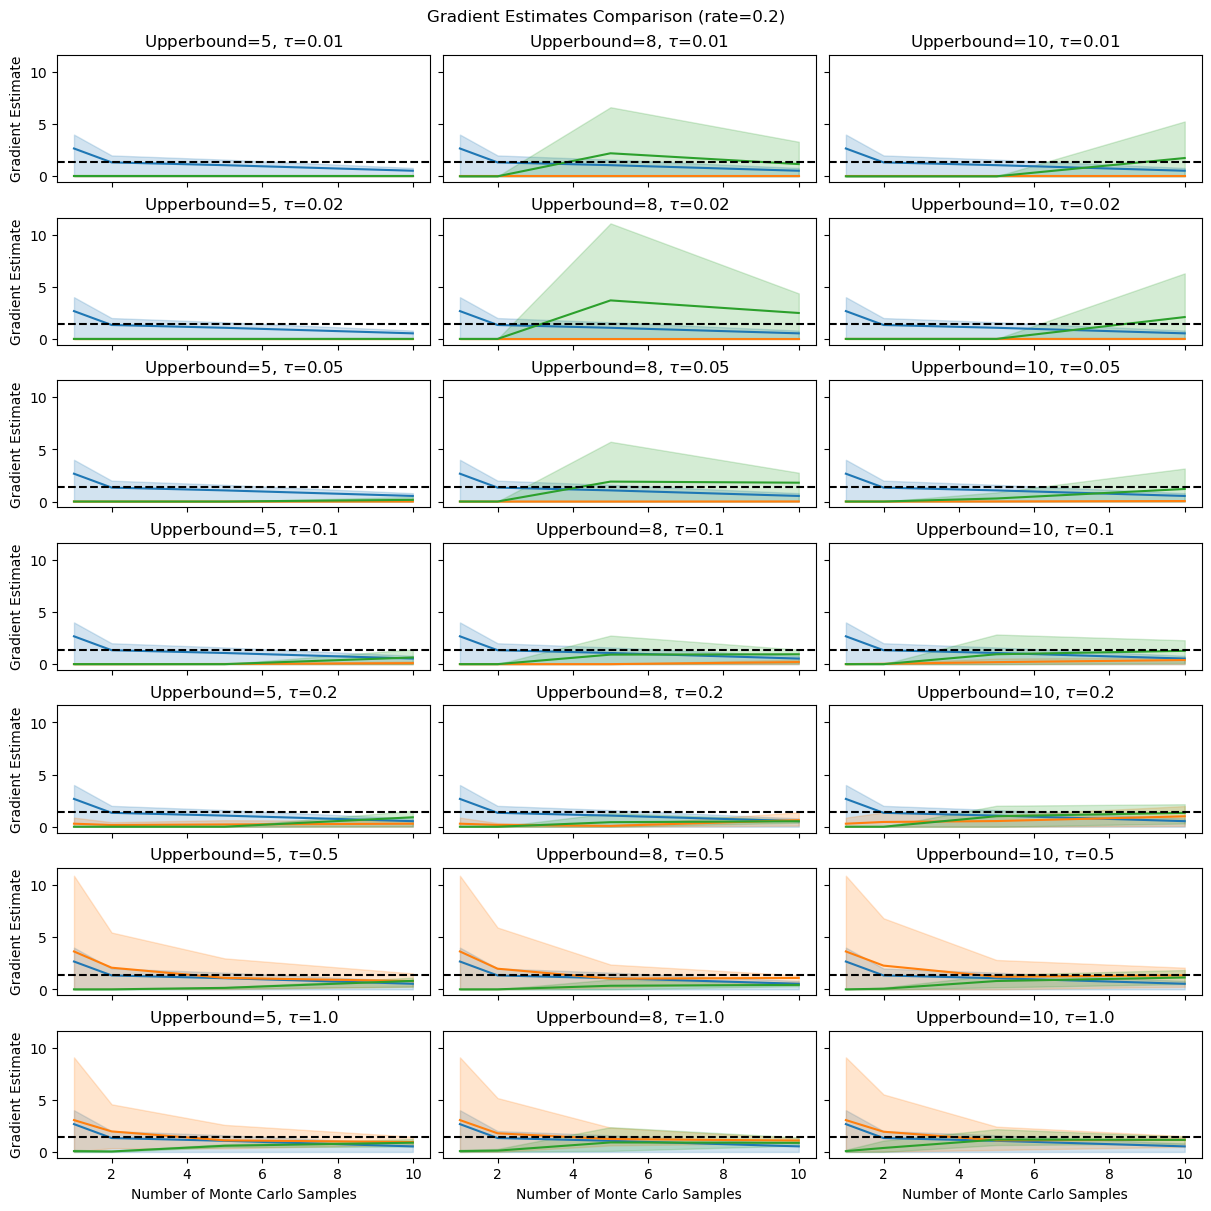

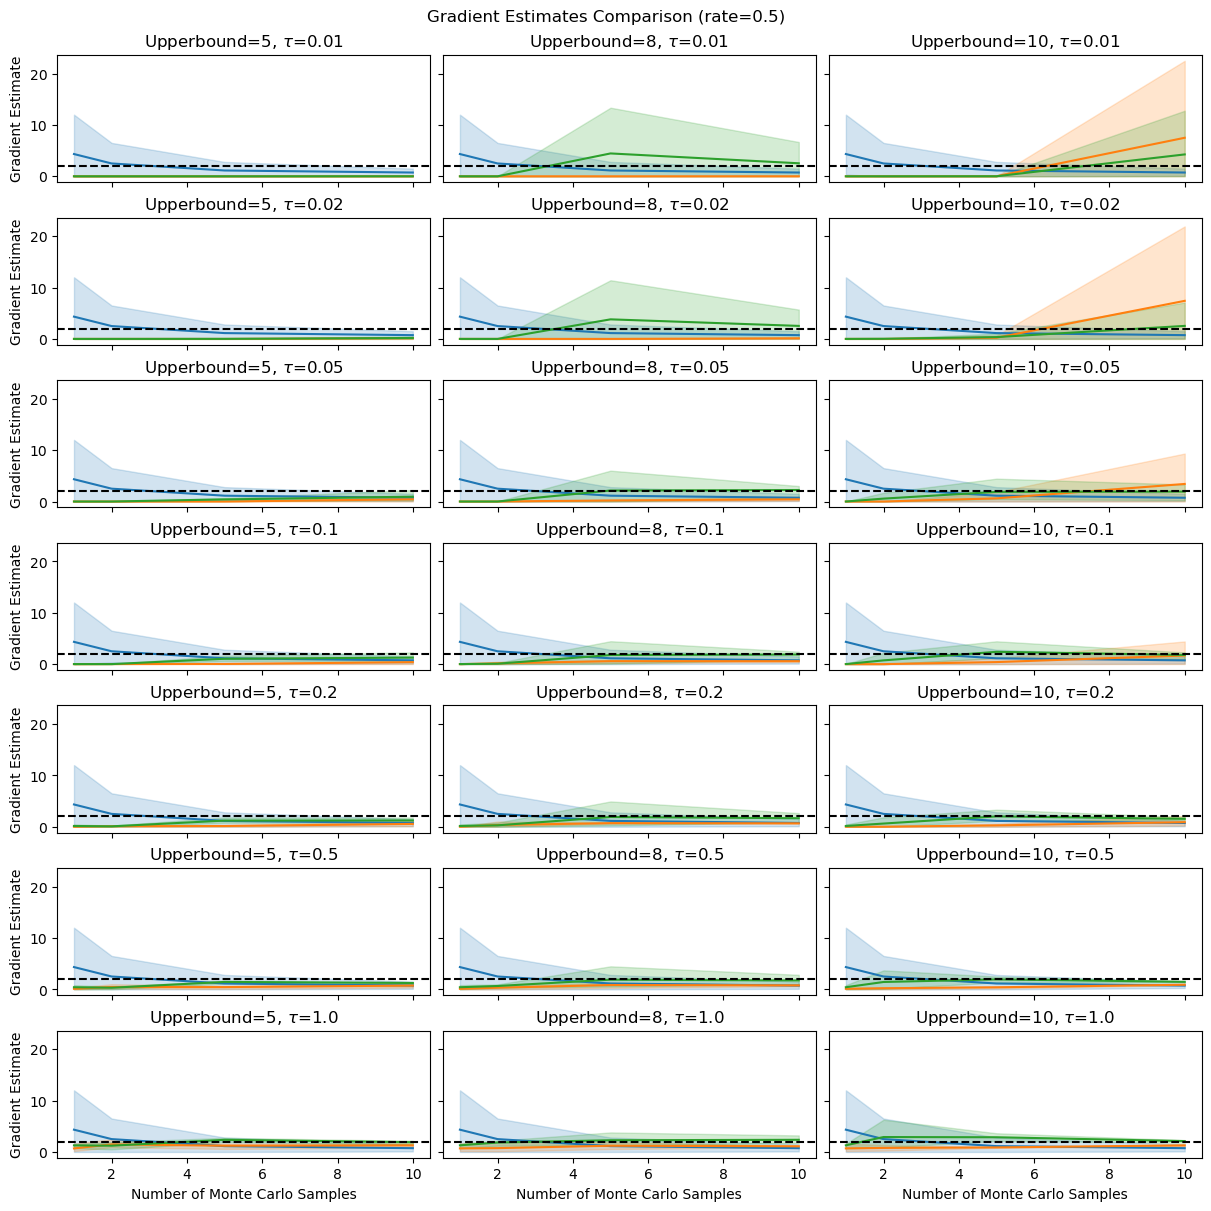

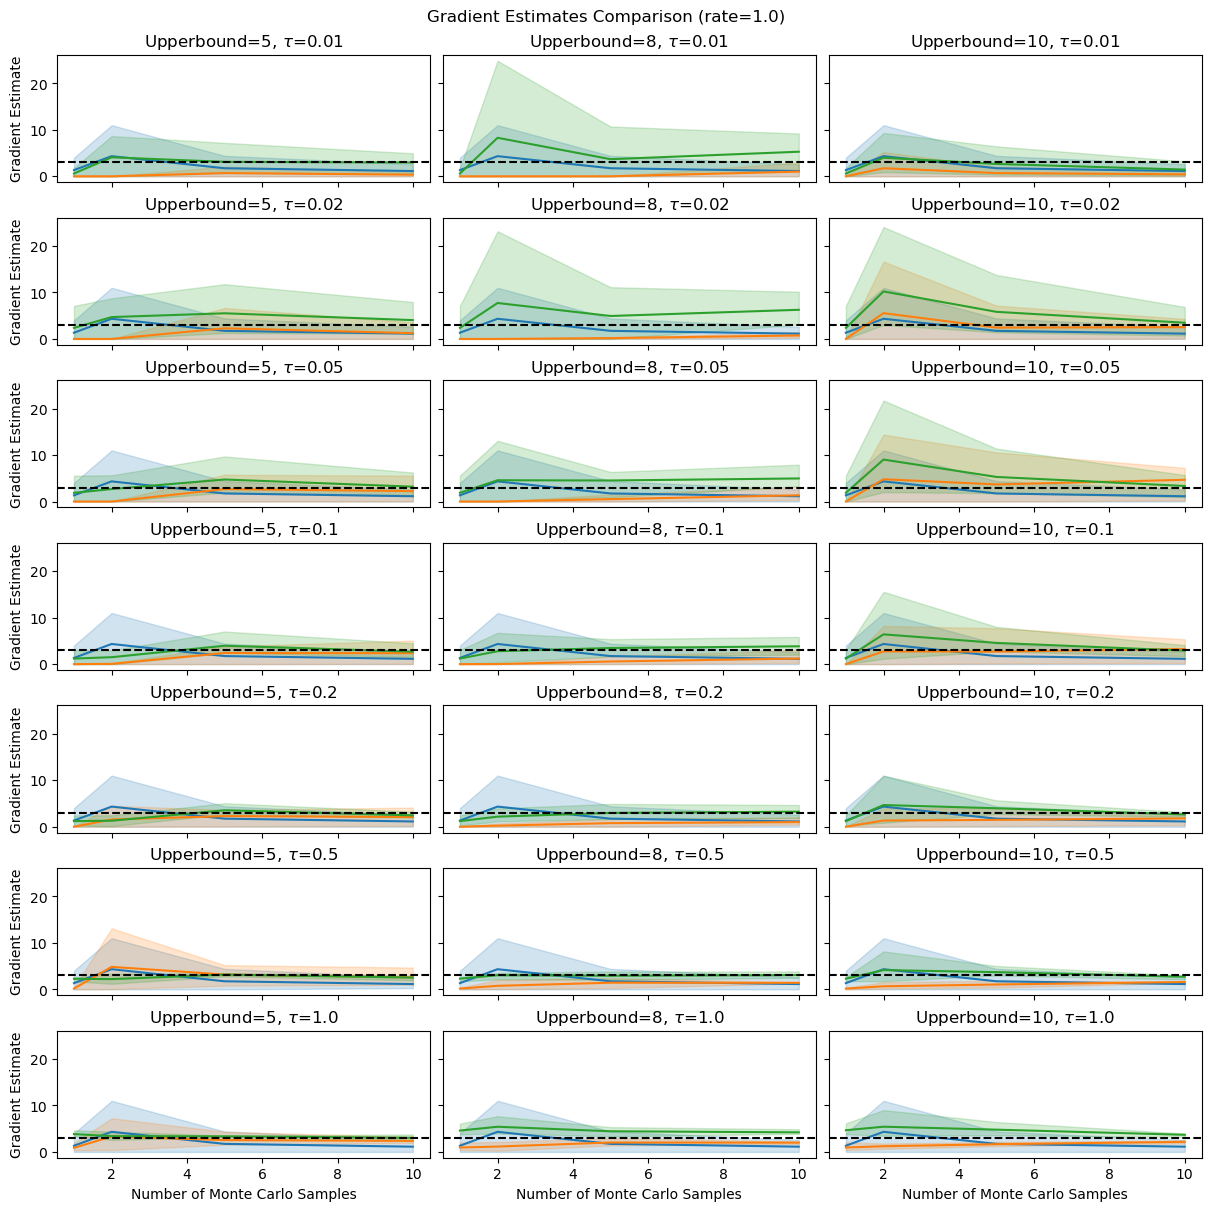

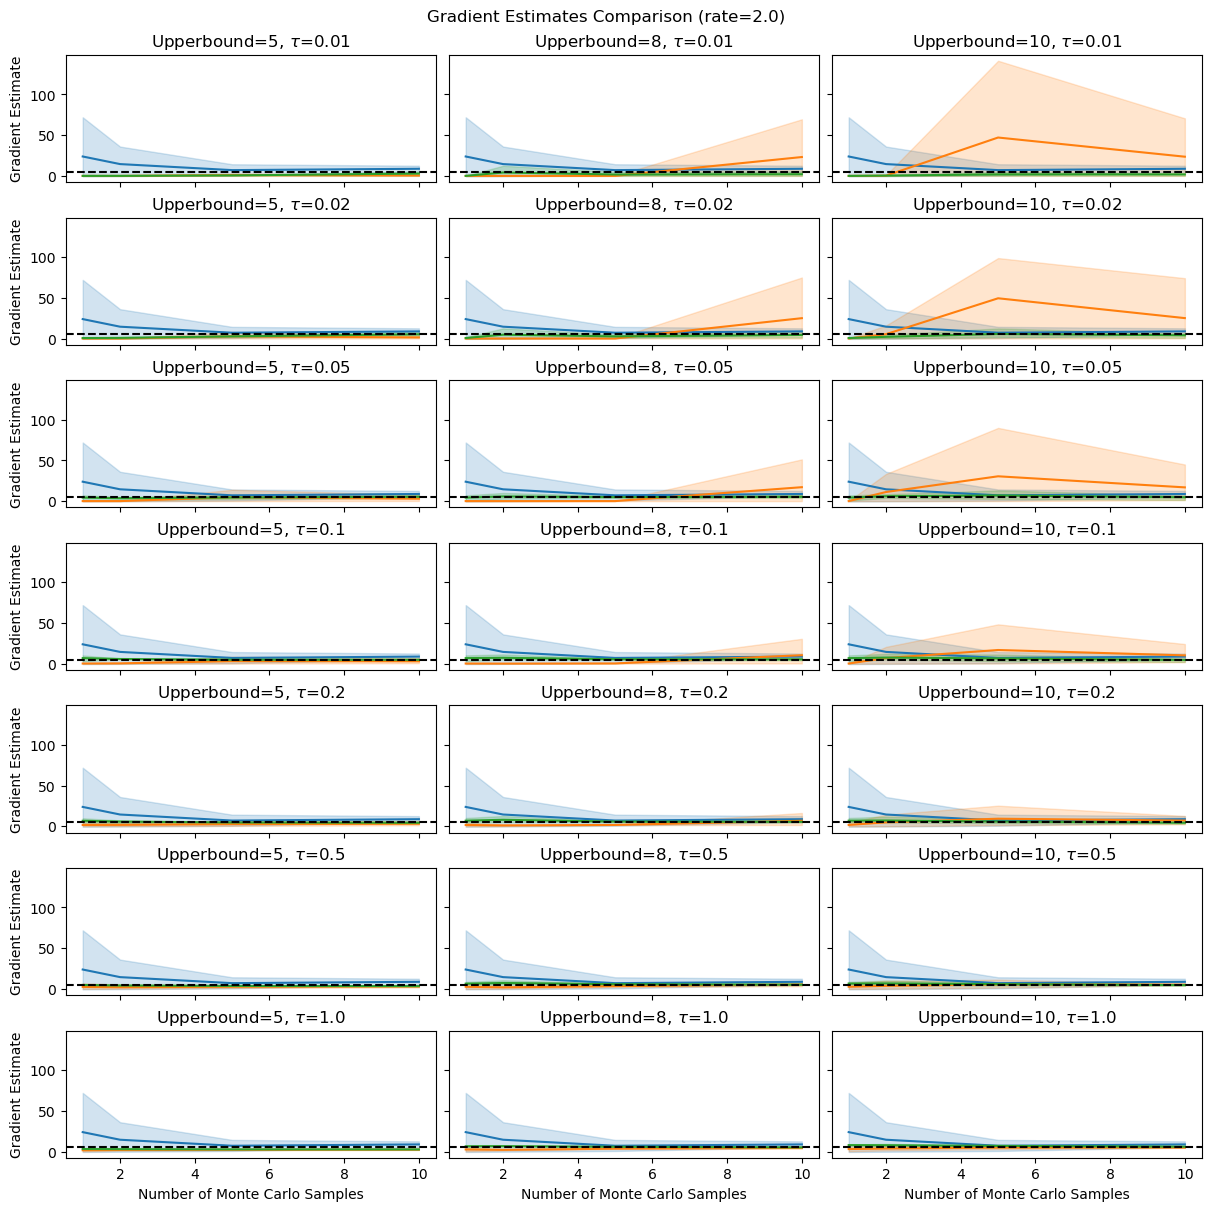

In [121]:
for rate in rate_list:

    fig, axs = plt.subplots(
        len(tau_list),
        len(upperbound_list),
        figsize=(12, 12),
        layout="constrained",
        sharey=True,
        sharex=True,
    )
    for i, tau in enumerate(tau_list):
        for j, upperbound in enumerate(upperbound_list):
            ax = axs[i, j]
            df_plot = df_result[
                (
                    (df_result["upperbound"] == upperbound)
                    & (df_result["$\\tau$"] == tau)
                    | (df_result["method"] == "score")
                )
                & (df_result["rate"] == rate)
            ]
            sns.lineplot(
                data=df_plot,
                x="n_monte_carlo",
                y="grad_estimate",
                hue="method",
                hue_order=["score", "GS", "exp"],
                ax=ax,
            )
            ax.axhline(
                y=f_grad_exact(rate), color="k", linestyle="--", label="True Gradient"
            )
            ax.set_title(f"Upperbound={upperbound}, $\\tau$={tau}")
            ax.set_xlabel("Number of Monte Carlo Samples")
            ax.set_ylabel("Gradient Estimate")
            ax.get_legend().remove()
    fig.suptitle(f"Gradient Estimates Comparison (rate={rate})")

    # fig, axs = plt.subplots(
    #     len(tau_list),
    #     len(upperbound_list),
    #     figsize=(12, 12),
    #     layout="constrained",
    #     sharey=True,
    #     sharex=True,
    # )
    # for i, tau in enumerate(tau_list):
    #     for j, upperbound in enumerate(upperbound_list):
    #         ax = axs[i, j]
    #         df_plot = df_result[
    #             (df_result["upperbound"] == upperbound) & (df_result["$\\tau$"] == tau)
    #             | (df_result["method"] == "score") & (df_result["rate"] == rate)
    #         ]
    #         sns.lineplot(
    #             data=df_plot,
    #             x="n_monte_carlo",
    #             y="time",
    #             hue="method",
    #             hue_order=["score", "GS", "exp"],
    #             ax=ax,
    #         )
    #         ax.set_title(f"Upperbound={upperbound}, $\\tau$={tau}")
    #         ax.set_xlabel("Number of Monte Carlo Samples")
    #         ax.set_ylabel("Time (seconds)")
    #         ax.get_legend().remove()
    # fig.suptitle(f"Time Comparison (rate={rate})")

## Adaptive upperbound

In [226]:
def f(z):
    return torch.cos(z) ** 2
    # return z**2
    # return z.sqrt()
    # return z**2 - 2 * z


# percentile = 1e-3
percentile = 1e-2

rate_list = [0.2, 0.5, 1.0, 2.0]
method_list = ["score", "GS", "exp"]
tau_list = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
n_monte_carlo_list = [1, 2, 5, 10, 20, 50, 100, 200, 500]
seed_list = np.arange(10)

In [223]:
df_result = []

for rate, method, tau, n_monte_carlo, seed in product(
    rate_list,
    method_list,
    tau_list,
    n_monte_carlo_list,
    seed_list,
):
    if method == "score" and (tau != tau_list[0]):
        continue
    torch.manual_seed(seed)
    rate_tensor = torch.tensor(rate, requires_grad=True)
    start_time = time.time()
    z_samples = sample_poisson(
        rate_tensor,
        method=method,
        n_monte_carlo=n_monte_carlo,
        upperbound=compute_upperbound(rate, p=percentile),
        tau=tau,
    )
    f_z = f(z_samples)
    if method == "score":
        loss = (f_z * poisson_log_prob(rate_tensor, z_samples)).mean()
    else:
        loss = f_z.mean()
    loss.backward()
    end_time = time.time()
    df_result.append(
        {
            "rate": rate,
            "method": method,
            "$\\tau$": tau,
            "n_monte_carlo": n_monte_carlo,
            "seed": seed,
            "time": end_time - start_time,
            "grad_estimate": rate_tensor.grad.item(),
        }
    )
    grad_estimate = rate_tensor.grad.item()
df_result = pd.DataFrame(df_result)

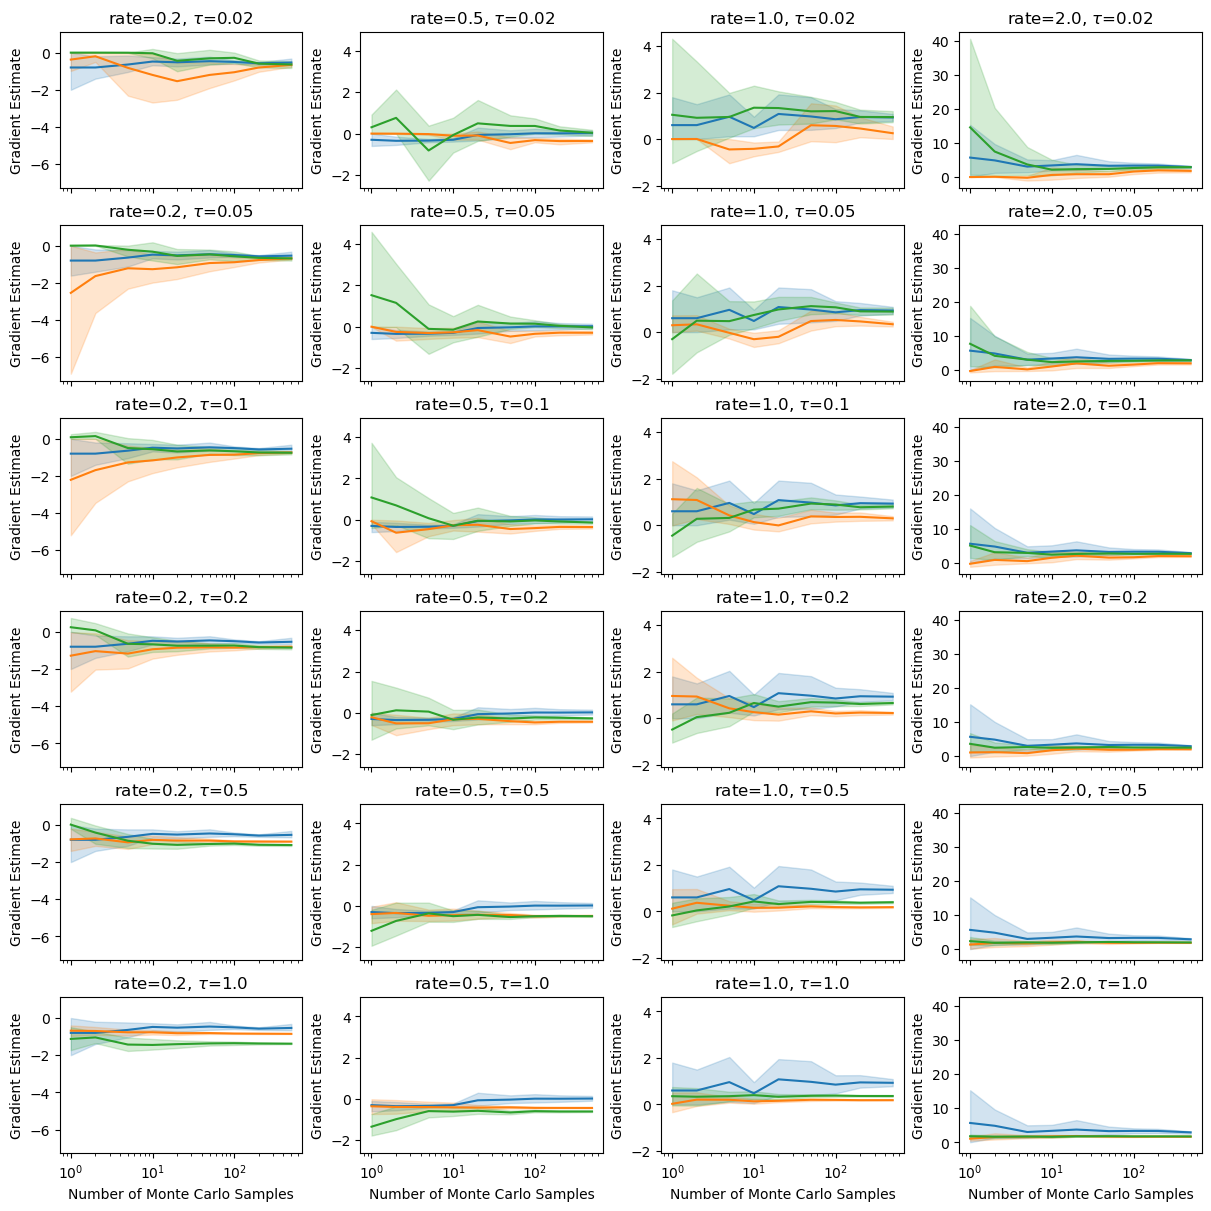

In [225]:
fig, axs = plt.subplots(
    len(tau_list),
    len(rate_list),
    figsize=(12, 12),
    layout="constrained",
    sharex=True,
    sharey="col",
)
for i, tau in enumerate(tau_list):
    for j, rate in enumerate(rate_list):
        ax = axs[i, j]
        df_plot = df_result[
            ((df_result["$\\tau$"] == tau) | (df_result["method"] == "score"))
            & (df_result["rate"] == rate)
        ]
        sns.lineplot(
            data=df_plot,
            x="n_monte_carlo",
            y="grad_estimate",
            hue="method",
            hue_order=["score", "GS", "exp"],
            ax=ax,
        )
        ax.set_title(f"rate={rate}, $\\tau$={tau}")
        ax.set_xlabel("Number of Monte Carlo Samples")
        ax.set_ylabel("Gradient Estimate")
        ax.get_legend().remove()
        ax.set_xscale("log")